In [ ]:
# Global Significant Earthquake Patterns, 1965-2016
### A Data Analysis Project

## 1. Problem Statement

**Data source:** "Significant Earthquakes, 1965-2016", originally compiled by the National Earthquake Information Center (NEIC), part of the U.S.
Geological Survey (USGS). It records the date, time, location, depth, and magnitude of every earthquake worldwide with a reported magnitude of 5.5 or
higher between 1965 and 2016.
    
- Original dataset page: https://www.kaggle.com/datasets/usgs/earthquake-database
- CSV used in this notebook (public Github mirror of the same Kaggle file): https://

The raw file contains 23,412 rows and 21 columns

**Main inquiry question:**
> How has the frequency, depth, and magnitude of significant global earthqaukes (M5.5+) evolved and varied between 1965 and 2016?

**Sub-questions:**
- **A (Trend):** How has the annual number of significant earthquakes changed from 1965 to 2016?
- **B (Comparison):** How do earthquake counts and average magnitudes compare across depth categories - shallow, intermediate, and deep?
- **C (Relationship):** Is there a relationship between an earthquake's depth and its magnitude?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.set_option("display.width", 140)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110})

In [2]:
df = pd.read_csv('database.csv')
print(df.shape)

(23412, 21)


In [3]:
# Shape
print("shape", df.shape)

#Column headers
print("Column Headers\n", df.columns.tolist())

# Data Types
print(df.dtypes)

shape (23412, 21)
Column Headers
 ['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error', 'Depth Seismic Stations', 'Magnitude', 'Magnitude Type', 'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap', 'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID', 'Source', 'Location Source', 'Magnitude Source', 'Status']
Date                              str
Time                              str
Latitude                      float64
Longitude                     float64
Type                              str
Depth                         float64
Depth Error                   float64
Depth Seismic Stations        float64
Magnitude                     float64
Magnitude Type                    str
Magnitude Error               float64
Magnitude Seismic Stations    float64
Azimuthal Gap                 float64
Horizontal Distance           float64
Horizontal Error              float64
Root Mean Square              float64
ID                               

In [4]:
# First 10 rows
print(df.head(10))

         Date      Time  Latitude  Longitude        Type  Depth  Depth Error  Depth Seismic Stations  Magnitude Magnitude Type  ...  \
0  01/02/1965  13:44:18    19.246    145.616  Earthquake  131.6          NaN                     NaN        6.0             MW  ...   
1  01/04/1965  11:29:49     1.863    127.352  Earthquake   80.0          NaN                     NaN        5.8             MW  ...   
2  01/05/1965  18:05:58   -20.579   -173.972  Earthquake   20.0          NaN                     NaN        6.2             MW  ...   
3  01/08/1965  18:49:43   -59.076    -23.557  Earthquake   15.0          NaN                     NaN        5.8             MW  ...   
4  01/09/1965  13:32:50    11.938    126.427  Earthquake   15.0          NaN                     NaN        5.8             MW  ...   
5  01/10/1965  13:36:32   -13.405    166.629  Earthquake   35.0          NaN                     NaN        6.7             MW  ...   
6  01/12/1965  13:32:25    27.357     87.867  Earthquak

In [ ]:
### Have an overview of the DataFrame
(shape, column headers, data types, first/last rows - the standard pandas overview checklist)

In [5]:
# Last 10 rows
print(df.tail(10))

             Date      Time  Latitude  Longitude        Type  Depth  Depth Error  Depth Seismic Stations  Magnitude Magnitude Type  ...  \
23402  12/24/2016  03:58:55   -5.1460   153.5166  Earthquake  30.00          1.8                     NaN        5.8            MWW  ...   
23403  12/25/2016  14:22:27  -43.4029   -73.9395  Earthquake  38.00          1.9                     NaN        7.6            MWW  ...   
23404  12/25/2016  14:32:13  -43.4810   -74.4771  Earthquake  14.93          3.3                     NaN        5.6             MB  ...   
23405  12/27/2016  23:20:56   45.7192    26.5230  Earthquake  97.00          1.8                     NaN        5.6            MWW  ...   
23406  12/28/2016  08:18:01   38.3754  -118.8977  Earthquake  10.80          1.3                    34.0        5.6             ML  ...   
23407  12/28/2016  08:22:12   38.3917  -118.8941  Earthquake  12.30          1.2                    40.0        5.6             ML  ...   
23408  12/28/2016  09:13:47

In [ ]:
## 2. Data Cleaning

### a. Drop unwanted features
Several columns are mostly empty and not relevant to our three questions (Depth Error, Depth Seismic Stations, Magnitude Error, Magnitude Seismic
Stations, Azimuthal Gap, Horizontal Distance, Horizontal Error, Root Mean Square - each 65-99% mission), plus bookkeeping fields (Location Source,
Magnitude Source, Source, Status) that add no analytical value here.

In [6]:
cols = df.columns
remove = ["Depth Error", "Depth Seismic Stations", "Magnitude Error", 
          "Magnitude Seismic Stations", "Azimuthal Gap", "Horizontal Distance", 
          "Horizontal Error", "Root Mean Square", "Location Source", 
          "Magnitude Source", "Source", "Status"]
df.drop(remove, inplace=True, axis=1)
print(df.shape)

(23412, 9)


In [ ]:
### b. Check the missing data

**Method #1:** Check the missing data in each column.

In [7]:
print(df.isnull().sum())

Date              0
Time              0
Latitude          0
Longitude         0
Type              0
Depth             0
Magnitude         0
Magnitude Type    3
ID                0
dtype: int64


In [ ]:
**Method #2:** Check the *percentage* of missing data in each column instead.

In [8]:
for c in df.columns: 
    pct_missing = (df[c].isnull().sum()) / df.shape[0] 
    print(c, round(pct_missing, 4))

Date 0.0
Time 0.0
Latitude 0.0
Longitude 0.0
Type 0.0
Depth 0.0
Magnitude 0.0
Magnitude Type 0.0001
ID 0.0


In [ ]:
### c. Address missing values

Only two columns have any missing data, and both are far below 1% of rows, so we repair them directly rather than dropping rows (Method #2 from the
slides - 'dropna()' - would be the right tool if a large chunk of rows ere affected, but that's not the case here).

- **Date / Time:** three rows store a single ISO-8601 timestamp instead of the standard 'mm/dd/yyyy' + 'hh:mm:ss' format. We reformat these to match
the rest of the column.
- **Magnitude Type:** three rows are missing this categorical field. "Replacing missing values with... the most frequent value" method, we fill with
the column's mode (using 'fillna, same pattern as filling 'num_room' with its median.

In [9]:
iso_mask = df["Date"].str.contains("T", na=False)
print("Rows with malformed ISO date/time:", iso_mask.sum())
print(df.loc[iso_mask, ["Date", "Time"]])

iso_dt = pd.to_datetime(df.loc[iso_mask, "Date"], utc=True)
df.loc[iso_mask, "Date"] = iso_dt.dt.strftime("%m/%d/%Y")
df.loc[iso_mask, "Time"] = iso_dt.dt.strftime("%H:%M:%S")

Rows with malformed ISO date/time: 3
                           Date                      Time
3378   1975-02-23T02:58:41.000Z  1975-02-23T02:58:41.000Z
7512   1985-04-28T02:53:41.530Z  1985-04-28T02:53:41.530Z
20650  2011-03-13T02:23:34.520Z  2011-03-13T02:23:34.520Z


In [10]:
mode_magtype = df["Magnitude Type"].mode()[0]
print("Mode Magnitude Type:", mode_magtype)
df["Magnitude Type"].fillna(mode_magtype, inplace=True)

print(df.isnull().sum().sum(), "missing values remain")

Mode Magnitude Type: MW
3 missing values remain


C:\Users\akin5\AppData\Local\Temp\ipykernel_23948\1830010875.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Magnitude Type"].fillna(mode_magtype, inplace=True)


In [ ]:
### d. Remove duplicates
Every earthquake record has an ID. We use that identifier as the criterion for 'drop_duplicates()'.

In [11]:
df_before = df.shape
df = df.drop_duplicates(subset=["ID"], keep="last")
print("Before:", df_before, " After:", df.shape)

Before: (23412, 9)  After: (23412, 9)


In [ ]:
### e. Fix structural errors - feature data types
'Date'/'Time are stored as text ('object'), which is roughly analogous to 'str' in native Python. Convert to proper 'DataTime' and derive
'Year'/'Month' fields

In [12]:
print(df["Date"].dtype) #object -- wrong, should be a real date

df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"], 
                                format="%m/%d/%Y %H:%M:%S", errors="coerce")
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
print(df["DateTime"].dtype)
print(df["Year"].value_counts(dropna=False).sort_index().head())

str
datetime64[us]
Year
1965    339
1966    234
1967    255
1968    305
1969    323
Name: count, dtype: int64


In [13]:
df["Type"] = df["Type"].astype("category")
df["Magnitude Type"] = df["Magnitude Type"].astype("category")
df.dtypes

Date                         str
Time                         str
Latitude                 float64
Longitude                float64
Type                    category
Depth                    float64
Magnitude                float64
Magnitude Type          category
ID                           str
DateTime          datetime64[us]
Year                       int32
Month                      int32
dtype: object

In [ ]:
### f. Check valid inputs for categorical features
A categorical feature has a limited number of values; sometimes typos or inconsistent casing creep in.

In [14]:
print(df["Type"].value_counts(dropna=False))
print()
print(df["Magnitude Type"].value_counts(dropna=False))

Type
Earthquake           23232
Nuclear Explosion      175
Explosion                4
Rock Burst               1
Name: count, dtype: int64

Magnitude Type
MW     7722
MWC    5669
MB     3761
MWB    2458
MWW    1983
MS     1702
ML       77
MWR      26
MD        6
MH        5
NaN       3
Name: count, dtype: int64


In [15]:
# Standardize casing defensively 
# uppercase is the seismological convention for magnitude-type codes (MW, MB, ...)
df["Magnitude Type"] = df["Magnitude Type"].str.upper()
df["Type"] = df["Type"].str.strip()

print(df["Magnitude Type"].value_counts(dropna=False))
print("\nNo inconsistent casing or typos found -- all category labels were already clean.")

Magnitude Type
MW     7722
MWC    5669
MB     3761
MWB    2458
MWW    1983
MS     1702
ML       77
MWR      26
MD        6
MH        5
NaN       3
Name: count, dtype: int64

No inconsistent casing or typos found -- all category labels were already clean.


In [ ]:
Type contains four values: Earthquake, Nuclear Explosion, Explosion, and Rock Burst. The latter three are man-made or mining-related seismic events
captured by the same monitoring network, not natural earthquakes, so we filter to keep only Earthquake records — consistent with this project's focus.

In [16]:
df = df[df["Type"] == "Earthquake"].copy()
df["Type"] = df["Type"].astype("category").cat.remove_unused_categories()
print("Rows remaining after keeping Type == 'Earthquake':", len(df))

Rows remaining after keeping Type == 'Earthquake': 23232


In [ ]:
### g. Identify numerical outliers
Following Boxplot for spotting outliers, look at 'Depth' and 'Magnitude' side by side using 'plt.subplots()' before deciding how to treat them.

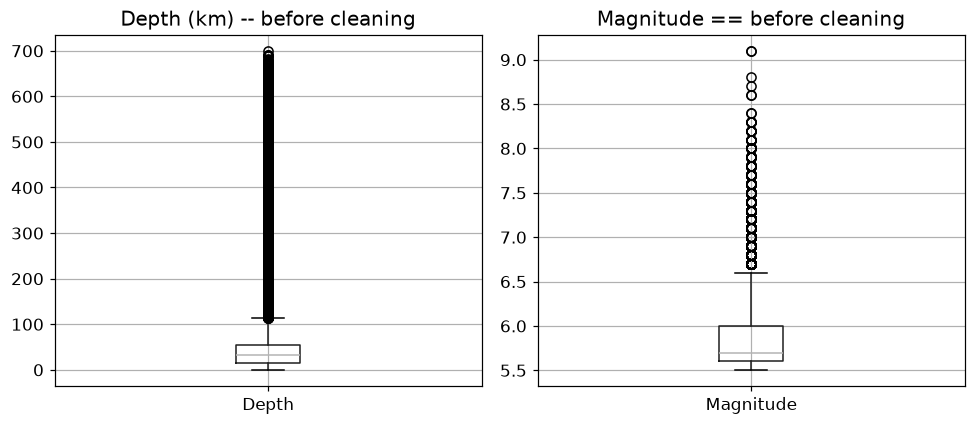

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
df.boxplot(column=["Depth"], ax=axes[0])
df.boxplot(column=["Magnitude"], ax=axes[1])
axes[0].set_title("Depth (km) -- before cleaning")
axes[1].set_title("Magnitude == before cleaning")
plt.tight_layout()
plt.show()

In [ ]:
Depth shows a few points below 0 on the boxplot - physically impossible, and a known artifact of the reference datum some regional networks use for
very shallow events. We locate them with NumPy boolean masking (the same 'arr[condition]' technique NumPy uses the remove elements by value or
    condition) and, since the earthquakes themselves are still valid records, clip the depth to 0 rather than deleting the rows outright:

In [18]:
neg_depth_n = (df["Depth"] < 0).sum()
print("Negative depth rows:", neg_depth_n)
print(df.loc[df["Depth"] < 0, ["Date", "Depth", "Magnitude"]])

# clip (Method #1: empirical observation -- we know depth cannot be negative)
df["Depth"] = df["Depth"].clip(lower=0)

Negative depth rows: 3
             Date  Depth  Magnitude
8099   07/21/1986 -0.076       5.60
10977  06/28/1992 -0.097       7.30
10978  06/28/1992 -1.100       5.77


In [19]:
# NumPY exercise: locate the same outliers directly on the underlying array
depth_arr = df["Depth"].to_numpy()
print("Any negative values left in the NumPy array?", (depth_arr < 0).any())

for col in ["Depth", "Magnitude"]: 
    q1, q3 = df[col].quantile([0.25, 0.75]) 
    iqr = q3 - q1 
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr 
    n_out = ((df[col] < lo) | (df[col] > hi)).sum() 
    print(f"{col}: IQR bounds [{lo:.2f}, {hi:.2f}] -> {n_out} rows flagged (kept; real seismic extremes)")

Any negative values left in the NumPy array? False
Depth: IQR bounds [-44.70, 114.50] -> 3239 rows flagged (kept; real seismic extremes)
Magnitude: IQR bounds [5.00, 6.60] -> 1471 rows flagged (kept; real seismic extremes)


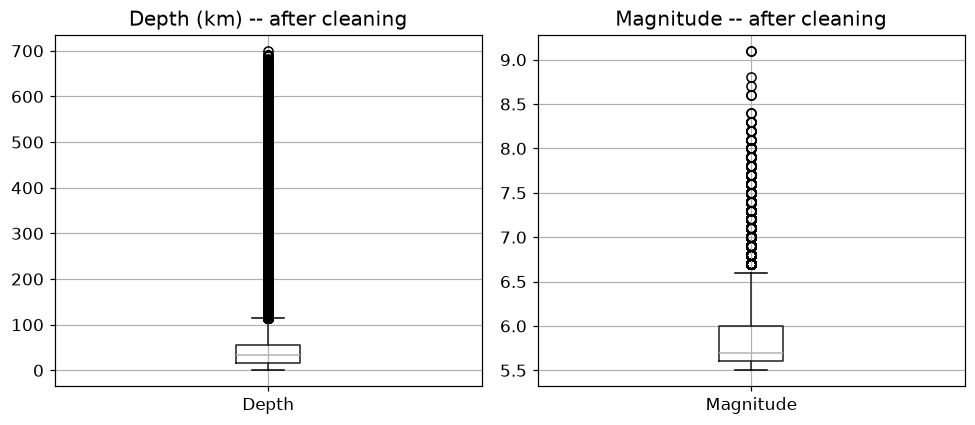

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
df.boxplot(column=["Depth"], ax=axes[0])
df.boxplot(column=["Magnitude"], ax=axes[1])
axes[0].set_title("Depth (km) -- after cleaning")
axes[1].set_title("Magnitude -- after cleaning")
plt.tight_layout()
plt.show()

In [ ]:
### h. Basic statistics with pandas
Get descriptive statistics for our two key numeric features.

In [21]:
print(df["Depth"].describe())
print("\nMedian Depth:", df["Depth"].median())
print()
print(df["Magnitude"].describe())
print("\nMedian Magnitude:", df["Magnitude"].median())

count    23232.000000
mean        71.313968
std        122.968352
min          0.000000
25%         15.000000
50%         33.000000
75%         54.800000
max        700.000000
Name: Depth, dtype: float64

Median Depth: 33.0

count    23232.000000
mean         5.882763
std          0.424032
min          5.500000
25%          5.600000
50%          5.700000
75%          6.000000
max          9.100000
Name: Magnitude, dtype: float64

Median Magnitude: 5.7


In [ ]:
## 3. Exploratory Data Analysis and Interpretation

### Question A: How has the annual number of significant earthquakes changed from 1965 to 2016?

**Process:** group the cleaned data by 'Year' and count rows to get an annual frequency table (a one-column pivot), then fit a linear trend line with
'np.polyfit' (NumPy).

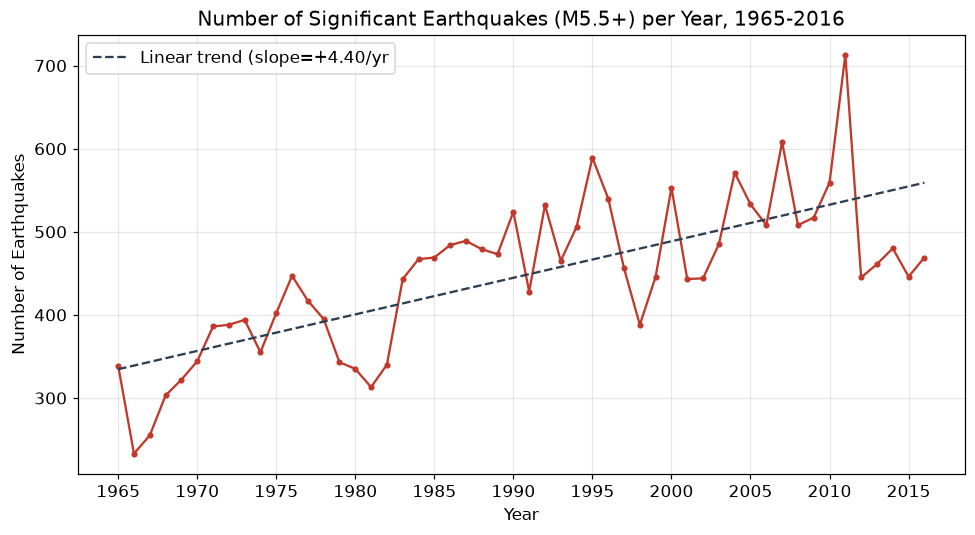

Correlarion of Year vs Count: r = 0.724
Trend slope: +4.40 extra earthquakes per year
Peak year: 2011 with 713 events


In [24]:
yearly = df.groupby("Year").size().reset_index(name="Count")
yearly = yearly[(yearly["Year"] >= 1965) & (yearly["Year"] <= 2016)]

z = np.polyfit(yearly["Year"], yearly["Count"], 1)
trend = np.poly1d(z)
corr_a = np.corrcoef(yearly["Year"], yearly["Count"])[0, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly["Year"], yearly["Count"], marker="o", markersize=3, linewidth=1.5, color="#c0392b")
ax.plot(yearly["Year"], trend(yearly["Year"]), linestyle="--", color="#2c3e50", 
        label=f"Linear trend (slope={z[0]:+.2f}/yr")
ax.set_title("Number of Significant Earthquakes (M5.5+) per Year, 1965-2016")
ax.set_xlabel("Year"); ax.set_ylabel("Number of Earthquakes")
ax.set_xticks(np.arange(1965, 2017, 5)) # custom tick spacing, NumPy arange
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Correlarion of Year vs Count: r = {corr_a:.3f}")
print(f"Trend slope: {z[0]:+.2f} extra earthquakes per year")
print(f"Peak year: {int(yearly.loc[yearly['Count'].idxmax(), 'Year'])} " 
      f"with {int(yearly['Count'].max())} events")

In [ ]:
**Result & Interpretation:** The number of significant earthquakes recorded per year rose from 339 in 1965 to a peak of 713 in 2011, with a positive
linear trend of about **+4.4 additional earthquakes per year** on average (r = 0.72). The 2011 spike coincides with the M9.1 Tohoku earthquake and its
many aftershocks off the coast of Japan. Importantly, this rising trend almost certainly reflects **improvements in global seismic monitoring
infrastructure** over five decades - more and better-instrumented stations detect and catalog more events - rather than the Earth actyally producing
more earthquakes each year

### Question B: How do earthquake counts and average magnitudes compare across depth categories?

**Process** bin 'Depth' into three standard seismological categories, then build a **pivot table** - 'pd.pivot_table(df,index=[...], values=[...],
aggfunc{...}, margins=True)' pattern, which adds an "All" totals row.

In [26]:
bins = [-0.1, 70, 300, 1000]
labels = ["Shallow (0-70km)", "Intermediate (70-300km)", "Deep (300km+)"]
df["DepthCategory"] = pd.cut(df["Depth"], bins=bins, labels=labels)

# Pivot table with multiple aggregation functions and a totals row (margins=True)
pivot_b = pd.pivot_table(df, index=["DepthCategory"], values="Magnitude", 
                         aggfunc=["count", "mean", "std"], 
                         margins=True, margins_name="All Depths", observed=False)
pivot_b.columns = ["Count", "MeanMagnitude", "StdMagnitude"]
pivot_b

,Count,MeanMagnitude,StdMagnitude
DepthCategory,,,
Shallow (0-70km),18515,5.883286,0.423769
Intermediate (70-300km),3391,5.859953,0.401928
Deep (300km+),1326,5.933786,0.475344
All Depths,23232,5.882763,0.424032


In [ ]:
We can cross-check the shallow-earthquake count from the pivot table two different ways taught: boolean indexing and '.query()'.

In [27]:
# Method #1: Boolean indexing
shallow_boolean = df[df["Depth"] < 70]

# Method #2: .query()
shallow_query = df.query("Depth < 70")

print("Boolean indexing count:", len(shallow_boolean))
print(".query() count: ", len(shallow_query))

Boolean indexing count: 18480
.query() count:  18480


In [ ]:
To make the depth-category summary self-describing, join it with a small lookup table of plain-language descriptions - a 'pd.merge()', as taught in 
Pandas

In [29]:
depth_notes = pd.DataFrame({ 
    "DepthCategory": ["Shallow (0-70km)", "Intermediate (70-300km)", "Deep (300km+)"], 
    "TypicalSetting": ["Crust / plate boundaries", "Subducting slab (upper)", "Subducting slab (lower mantle)"],
})

pivot_b_labeled = pd.merge(pivot_b.reset_index(), depth_notes, on="DepthCategory", how="left")
pivot_b_labeled

,DepthCategory,Count,MeanMagnitude,StdMagnitude,TypicalSetting
0,Shallow (0-70km),18515,5.883286,0.423769,Crust / plate boundaries
1,Intermediate (70-300km),3391,5.859953,0.401928,Subducting slab (upper)
2,Deep (300km+),1326,5.933786,0.475344,Subducting slab (lower mantle)
3,All Depths,23232,5.882763,0.424032,NaN


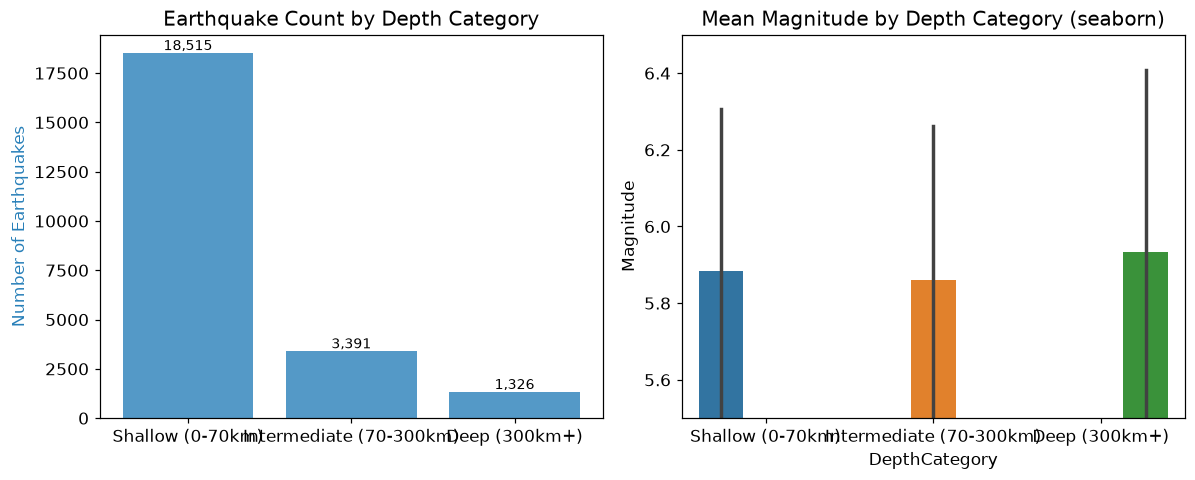

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: matplotlib bar chart (count by category)
plot_data = pivot_b.drop(index="All Depths")
axes[0].bar(plot_data.index, plot_data["Count"], color="#2980b9", alpha=0.8)
axes[0].set_ylabel("Number of Earthquakes", color="#2980b9")
axes[0].set_title("Earthquake Count by Depth Category")
for i, c in enumerate(plot_data["Count"]): 
    axes[0].text(i, c + 150, f"{int(c):,}", ha="center", fontsize=9)
    
# Right: seaborn barplot with a mean estimator
sns.barplot(x="DepthCategory", y="Magnitude", data=df, estimator=np.mean, 
            errorbar="sd", ax=axes[1], hue="DepthCategory", legend=False)
axes[1].set_title("Mean Magnitude by Depth Category (seaborn)")
axes[1].set_ylim(5.5, 6.5)
plt.tight_layout()
plt.show()

In [ ]:
**Result & Interpretation:** The overwhelming majority of significant earthquakes (about 80%) occur at shallow depths of less than 70 km, consistent
with the fact that most tectonic plate boundaries - where stress builds up and releases as earthquakes - lie in the Earth's crust and upper mantle. 
Deep earthquakes (300 km+) are far less common (about 6% of events), but have a slightly higher average magnitude (5.93 vs. 5.88 for shallow events) 
and also show the widest spread (highest standard deviation), suggesting deep earthquakes are rarer but their magnitudes are somewhat more variable.
    
### Question C: Is there a relationship between an earthquake's depth and its magnitude?
    
**Process:** compute the Pearson correlation between Depth and Magnitude on the full cleaned dataset (NumPy's 'np.corrcoef), and visualize with a
scatter plot in the same style as Data Visualization ('plt.scatter(x, y, marker='o', color=...)'). A random sample of 4,000 points is plotted for
visual clarity.

Pearson r (Depth vs Magnitude) = 0.0232


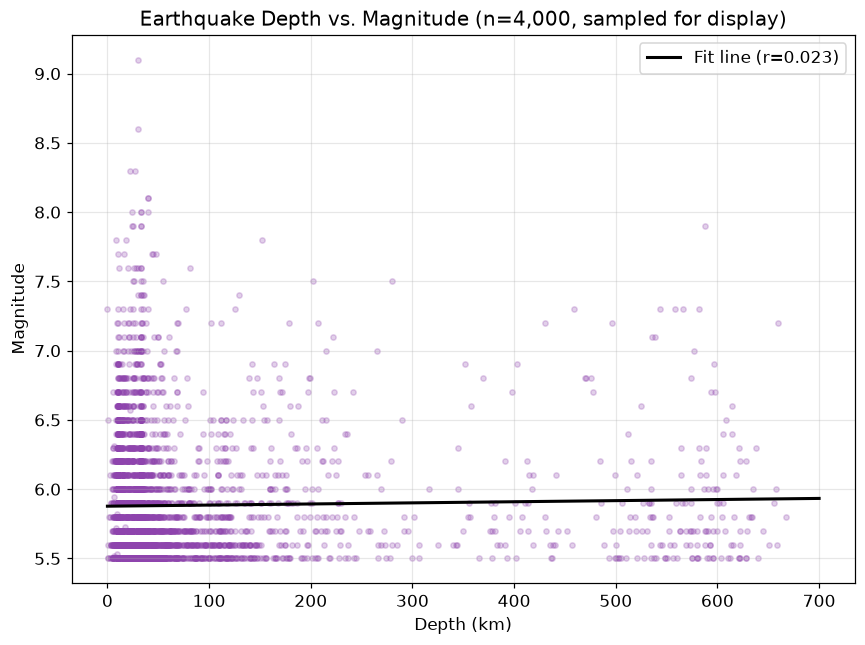

In [33]:
corr_c = df["Depth"].corr(df["Magnitude"])
print(f"Pearson r (Depth vs Magnitude) = {corr_c:.4f}")

sample = df.sample(n=min(4000, len(df)), random_state=42)
z2 = np.polyfit(df["Depth"], df["Magnitude"], 1)
xs = np.linspace(df["Depth"].min(), df["Depth"].max(), 100)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample["Depth"], sample["Magnitude"], marker="o", color="#8e44ad", alpha=0.25, s=12)
ax.plot(xs, np.poly1d(z2)(xs), color="black", linewidth=2, label=f"Fit line (r={corr_c:.3f})")
ax.set_xlabel("Depth (km)"); ax.set_ylabel("Magnitude")
ax.set_title(f"Earthquake Depth vs. Magnitude (n={len(sample):,}, sampled for display)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
***Result & Interpretation:** The Pearson correlation between depth and magnitude is **r=0.02** - essentially zero. This means that, across this
global catalog of M5.5+ earthquakes, how deep an earthquake occurs tells us almost nothing about how string it will be. The scatter plot visually
confirms this: high-magnitude and low-magnitude earthquakes both occur across the full range of depths, from the surface down to 700 km. This is a
useful (if sligtly counter-intuitive) finding - magnitude is governed by the size and slip of the fault rupture, not simply by how deep the rupture
occurs.
    
### Bonus: Distribution of magnitude (seaborn histogram with density curve)
As a complement to Question C, look at the overall **shape** of the magnitude variable itself using 'sns.histplot(..., kde=True)'

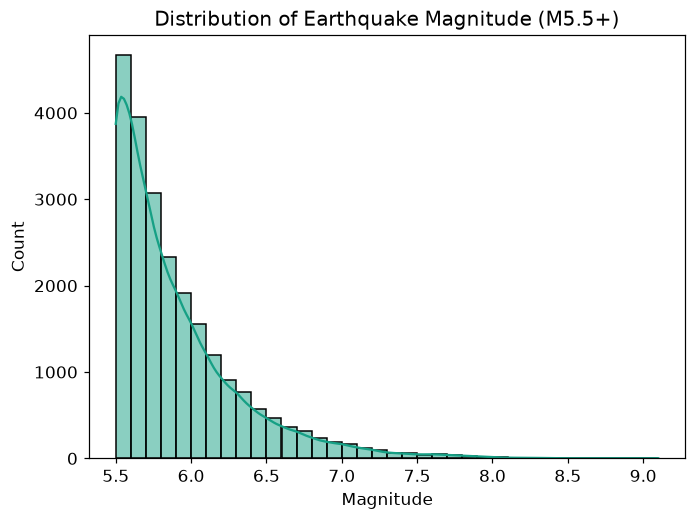

count    23232.000000
mean         5.882763
std          0.424032
min          5.500000
25%          5.600000
50%          5.700000
75%          6.000000
max          9.100000
Name: Magnitude, dtype: float64


In [34]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df["Magnitude"], kde=True, binwidth=0.1, color="#16a085")
plt.title("Distribution of Earthquake Magnitude (M5.5+)")
plt.xlabel("Magnitude")
plt.show()

print(df["Magnitude"].describe())

In [ ]:
**Interpretation:** The magnitude distribution is right-skewed with a long tail - most significant earthquakes cluster tightly between M5.5 and M6.0
(the lower bound of this catalog), and progressively larger earthquakes become rarer, with only a handful reaching M8+ (including the M9.1 2011 Tohoku
earthquake, the largest in the dataset).
    
### Bonus: NumPy - sorting and broadcasting
Two quick NumPy exercises: **sorting** an array to find the largest values, and **broadcasting** a scalar conversion across an entire array without a
loop.

In [35]:
# Sorting (np.wort) -- find the 10 largest magnitudes in the whole catalog
mag_arr = df["Magnitude"].to_numpy()
sorted_desc = np.sort(mag_arr)[::-1] # np.sort() then reverse,
print("Top 10 magnitudes on record:", sorted_desc[:10])

# Broadcasting -- convert every depth from km to miles in one vectorized operation
# (NumPy applies the scalar to every element without an explicit loop)
depth_km = df["Depth"].to_numpy()
depth_miles = depth_km * 0.621371
print("\nFirst 5 depths in km: ", np.round(depth_km[:5], 2))
print("First 5 depths in miles:", np.round(depth_miles[:5], 2))

Top 10 magnitudes on record: [9.1 9.1 8.8 8.7 8.6 8.6 8.4 8.4 8.3 8.3]

First 5 depths in km:  [131.6  80.   20.   15.   15. ]
First 5 depths in miles: [81.77 49.71 12.43  9.32  9.32]


In [ ]:
## 4. Summary

### Main findings
- The number of recorded significant earthquakes per year has risen noticeably from 1965 to 2016, but this trend most likely reflects improvements in
global seismic detection technology over time rather than a true increase in seismic activity.
- About 80% of significant earthquakes occur at shallow depths (under 70 km), matching what is known about tectonic plate boundary activity; deep
earthquakes (300 km+) are rare but tend to have a slightly higher and more variable magnitudes.
- Earthquake depth and magnitude are essentially uncorrelated (r = 0.02) in this dataset - knowing how deep an earthquake is gives almost no
information about hoe large it will be.
- The magnitude distribution itself is right-skewed, clustering just above the M5.5 catalog threshold with a long tail toward rare, very large
earthquakes.
    
### What this project did not resolve
This datset does not include a reliable place-name or ountry field, which prevented a true geographic/regional comparison that would require joining
the latitude/longitude coordinates to a geographic boundary dataset (another use case for 'pd.merge'). The rising trend in annual counts is also only
an association with time; this project did not have data on the number and sensitivity of seismic monitoring stations over the decades, so it cannot
fully separate "more earthquakes" from "better detection or earthquakes" as competing explanations.

### Directions for further exploration
- Join earthquake coordinates to country/tectonic-plate boundary shapefiles(via 'pd.merge' or a spatial join) to compare earthquake frequency and
magnitude by region or plate boundary type.
- Bring in historical data on the number of operation seismograph stations per decade to test how much of the rising yearly count is a detection
artifact versus a real increase.
- Extend the dataset beyond 2016 using USGS's live earthquake feed to see whether the recent-year patterns found here still hold in the most current
data.